# Comparison between Offline Methods

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pickle

list_df = []
for num in [20, 30, 40, 50, 60, 70, 90, 120, 150]:
    scenario_name = f'ev_scenario-{num}'
    pickle_result = f'./offline/metrics_{scenario_name}'
    num = int(scenario_name.split('-')[1])
    dir_scenario = f'./offline/ev_scenario-{num}/'
    
    scenarios_results = []
    with open(f"{pickle_result}.pickle", "rb") as f:
        results = pickle.load(f)

    df_ = pd.DataFrame(columns=list(results[0].keys()))
    for i, res in enumerate(results):
        df_.loc[i] = list(res.values())
    df_['Algorithm'] = df_['filename'].apply(lambda x: x.split('-')[0].upper())
    df_['Scenarios'] = scenario_name
    list_df.append( df_ )

list_df = pd.concat( list_df )
list_df['timeout'] = list_df['timeout'].astype(float)
list_df['GAP_P1'] = list_df['GAP_P1'].astype(float)
list_df['GAP_P2'] = list_df['GAP_P2'].astype(float)
list_df['GAP_P3'] = list_df['GAP_P3'].astype(float)
list_df['reward value'] = list_df['reward value'].astype(float)
list_df['solved'] = list_df['solved'].astype(float)
TO_time = 1800

df_res = list_df.copy()
df_res['Timeout'] = df_res['computation_time'].apply(lambda e: 1. if e >= TO_time else 0.)
df_res['Computation Time'] = df_res['computation_time'].apply(lambda e: TO_time if e >= TO_time else e)
df_res['Scenarios'] = df_res['Scenarios'].replace({**{f'ev_scenario-{num}': f'Scenario {num} EVs' for num in [20, 30, 40, 50, 60, 70, 90, 120, 150]}})
df_res['num'] = df_res['filename'].apply(lambda e: e.split('-')[-1].split('.')[0])
df_res = df_res[['Scenarios', 'Algorithm', 'Computation Time', 'Timeout', 'GAP_P1', 'GAP_P2', 'GAP_P3', 'solved', 'reward value', 'num']]

df_res = df_res[(df_res['Algorithm'] == 'COMPLETE_MILP_GUROBI')]
df_res['Algorithm'] = df_res['Algorithm'].replace({'COMPLETE_MILP_GUROBI': 'MILP'})

default_values = {
    'Computation Time': 1800.0,  # Default computation time
    'Timeout': 1.0,              # Default timeout
    'GAP_P1': 0.,
    'GAP_P2': 0.,
    'GAP_P3': 0.,
    'solved': 0.,
}

expanded_df = pd.DataFrame()
for (scenario, algorithm), group in df_res.groupby(['Scenarios', 'Algorithm']):
    rows_to_add = 100 - len(group)
    if rows_to_add > 0:
        additional_rows = {key: [value] * rows_to_add for key, value in default_values.items()}
        additional_rows['Scenarios'] = [scenario] * rows_to_add
        additional_rows['Algorithm'] = [algorithm] * rows_to_add
        additional_df = pd.DataFrame(additional_rows)
        group = pd.concat([group, additional_df], ignore_index=True)
    expanded_df = pd.concat([expanded_df, group], ignore_index=True)

In [16]:
expanded_df.groupby(['Scenarios', 'Algorithm']).agg({
    'Computation Time': ['median', 'mean', 'std'],  # Get median, mean, and std for computation time
    'Timeout': ['sum'],
})

Computation Time                          Timeout
                                     median         mean         std     sum
Scenarios        Algorithm                                                  
Scenario 120 EVs MILP           1800.000000  1799.813073    1.869275    99.0
Scenario 150 EVs MILP           1800.000000  1800.000000    0.000000   100.0
Scenario 20 EVs  MILP              0.473197    22.385484  178.860527     0.0
Scenario 30 EVs  MILP              6.721889   459.890859  729.183506    19.0
Scenario 40 EVs  MILP           1800.000000  1290.369336  762.802234    66.0
Scenario 50 EVs  MILP           1800.000000  1524.868329  607.048181    80.0
Scenario 60 EVs  MILP           1800.000000  1651.873205  443.728075    89.0
Scenario 70 EVs  MILP           1800.000000  1756.241072  238.772013    96.0
Scenario 90 EVs  MILP           1800.000000  1800.000000    0.000000   100.0

# General Comparative Results

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def global_cost_distribution_perc_on_lb(data, selected_scenarios, bar_width=.6, space_between_groups=.1,
                                        figsize=(20, 10), scenario_pad=70):
    def manually_parse_rewards(reward_string):
        try:
            rewards = reward_string.strip('[]').split()
            return [float(reward) for reward in rewards]
        except:
            return []

    data['Parsed Detailed Rewards'] = data['Detailed obj. cost'].apply(manually_parse_rewards)
    expanded_data = pd.DataFrame(columns=['Scenario', 'Algorithm', 'Cost'])
    for index, row in data.iterrows():
        for reward in row['Parsed Detailed Rewards']:
            expanded_data = expanded_data.append({
                'Scenario': row['Scenario'],
                'Algorithm': row['Algorithm'],
                'Reward': reward
            }, ignore_index=True)
    
    unique_algorithms = ['MILP', 'Baseline', 'PS2C', 'MPPO', 'Rolling']
    colors = ['#006400', '#008B8B', '#8B0000', '#00008B', '#9400D3', '#FF8C00', '#A9A9A9', '#808080']
    color_map = dict(zip(unique_algorithms, colors))
    fig, ax = plt.subplots(figsize=figsize)
    group_width = len(unique_algorithms) * bar_width + (len(unique_algorithms) - 1) * bar_width
    
    bar_positions = []
    scenario_positions = [i * (group_width + space_between_groups) + group_width / 3.01 for i in range(len(selected_scenarios))]
    algorithm_labels = []
    optimal_value = []
    optimal_value_no_wg = []
    
    for i, scenario in enumerate(selected_scenarios):
        algorithm = 'MILP'
        rewards = expanded_data[(expanded_data['Scenario'] == scenario) & (expanded_data['Algorithm'] == algorithm)]['Reward']
        gaps = df_res[(df_res['Scenarios'] == scenario) & (df_res['Algorithm'] == algorithm)]['GAP_P1']
        assert len(gaps) == len(rewards)
        opt_rewards = rewards.to_numpy() * ( 1 + gaps.to_numpy() )
        optimal_value.append( np.median(opt_rewards) )
        
    for i, scenario in enumerate(selected_scenarios):
        scenario_position = i * (group_width + space_between_groups)
        for j, algorithm in enumerate(unique_algorithms):
            algorithm_position = scenario_position + j * bar_width
            bar_positions.append(algorithm_position)
            rewards = expanded_data[(expanded_data['Scenario'] == scenario) & (expanded_data['Algorithm'] == algorithm)]['Reward']
            if not rewards.empty:
                parts = ax.violinplot(rewards / optimal_value[i] * 100, positions=[algorithm_position], showextrema=False, showmedians=True)
                # Remove fill color and set border style
                for i, pc in enumerate(parts['bodies']):
                    pc.set_facecolor('none')  # Remove fill color
                    pc.set_edgecolor(colors[j])  # Set edge color to black
                    pc.set_linewidth(3.0)  # Set larger border
                    pc.set_alpha(0.4)
                parts['cmedians'].set_edgecolor(colors[j])
                parts['cmedians'].set_alpha(0.5)
                parts['cmedians'].set_linewidth(1.5)
            algorithm_labels.append(algorithm)
    
    ax.set_xticks(scenario_positions)
    ax.set_xticklabels(selected_scenarios, verticalalignment='top', horizontalalignment='right', weight='bold', fontsize=13)
    ax.set_xticks(bar_positions, minor=True)
    ax.set_xticklabels(algorithm_labels, minor=True, rotation=30, verticalalignment='top', horizontalalignment='right', fontsize=12)
    ax.tick_params(axis='x', which='major', pad=scenario_pad, rotation=0, length=0)  # Add space between major ticks (scenarios) and their labels
    ax.set_xlabel('Scenarios and Algorithms', fontsize=16, labelpad=20)
    ax.set_ylabel('Relative Reward to Median Lower Bound (in %)', fontsize=16)
    ax.grid(True, linestyle='-', linewidth=.5, axis='y')
    plt.savefig('dist_obj_perc_on_lb.png', dpi=600, bbox_inches='tight')
    plt.show()


In [3]:
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999
directory_with_name_list = [('offline', 'offline'),
                            ('rule_based', 'rbc'),
                            ('rolling', 'rolling'),
                            ('reinforcement_learning', 'CustomMPPO')]
columns_selected = ['Algorithm', 'Obj. cost', 'Charging satisf. <80%', 'Charging satisf. >=80%', 'Overall charging satisf.', 'Price', 'Total Energy', 'RES used', 'Energy/EV', 'scenario_name']
scenario_name_dic = {
    50:  'scenario-50',
    60:  'scenario-60',
    70:  'scenario-70',
    90:  'scenario-90',
    120: 'scenario-120',
    150: 'scenario-150',
}

list_df = []
for (dir_name, method_name) in directory_with_name_list:
    for scn_num in scenario_name_dic:
        list_df.append( pd.read_csv(f"./{dir_name}/analysis_{method_name}_{scn_num}.csv",
                                    sep='\t') )
        if(method_name == 'CustomMPPO'):
            list_df[-1] = list_df[-1].loc[(list_df[-1]['Algorithm'] == 'MPPO_eval')]
        
        list_df[-1]['Scenario'] = scenario_name_dic[scn_num]
        list_df[-1]['Scenario'] = list_df[-1]['Scenario'].replace({**{f'scenario-{num}': f'Scenario {num} EVs' for num in [50, 60, 70, 90, 120, 150]}})
        list_df[-1]['Algorithm'] = list_df[-1]['Algorithm'].replace({'COMPLETE_MODEL': 'MILP', 'BASELINE': 'Baseline', 'PS2C': 'PS2C', 'MPPO_eval': 'MPPO', 'ROLLING': 'Rolling'})
        list_df[-1] = list_df[-1][(list_df[-1]['Algorithm'] == 'MILP') | (list_df[-1]['Algorithm'] == 'Baseline') | (list_df[-1]['Algorithm'] == 'PS2C') | (list_df[-1]['Algorithm'] == 'MPPO') | (list_df[-1]['Algorithm'] == 'Rolling')]

df = pd.concat( list_df )
df.sort_values(by=['Scenario', 'Algorithm'])

,Algorithm,Charging satisf. <80%,Charging satisf. >=80%,Overall charging satisf.,Overall charging unsatisf.,Charging auto rejection,Price,Grid limit,Total Energy,Total PV,PV used,Grid used,PV used/Total PV,PV used/Total Energy,Energy/EV,SoC charged,Final SoC,Waiting Time,Obj. cost,Detailed obj. cost,Detailed PV used,Detailed Total Energy,Detailed Total PV,Scenario
3,Baseline,26.97±3.98%,30.35±4.08%,57.32±4.03%,42.67±4.04%,20.68±3.60%,86.72±16.34,0.0,1320.24±98.47,284.89±127.98,281.83±125.69,1038.41±103.21,99.16±2.09%,21.03±9.04%,19.23±1.32,38.89±2.66%,79.13±2.63%,7.05±0.74,4243.08±513.59,[5085.59573577 4055.51520757 4892.67811855 471...,[418.94372 363.24255409 449.03847038 437.17...,[1462.98636227 1208.09047836 1422.25728492 143...,[418.94372 424.96714 453.08959 437.17869 430.0...,Scenario 120 EVs
0,MILP,8.34±3.38%,54.53±4.27%,62.87±3.40%,37.12±3.41%,3.74±2.58%,76.31±16.04,0.0,1202.69±74.23,284.89±127.98,280.65±125.29,922.04±124.48,98.83±2.97%,23.23±10.30%,15.95±0.77,32.66±1.47%,77.77±1.66%,5.33±0.70,7222.19±539.45,[7325.394372 7174.73630763 7600.32278538 780...,[418.94372 372.232855 444.23885625 435.73...,[1265. 1124.86977875 1241.0110025 127...,[418.94372 424.96714 453.08959 437.17869 430.0...,Scenario 120 EVs
1,MPPO,12.62±2.96%,36.88±3.54%,49.50±3.43%,50.49±3.43%,0.72±1.54%,77.36±15.17,0.0,1221.13±71.51,284.89±127.98,281.47±125.32,939.66±114.46,99.09±1.95%,22.87±10.00%,20.61±1.17,41.67±2.37%,86.38±1.80%,2.90±0.41,4942.64±448.68,[4565.8054328 5012.61992418 5126.50016887 536...,[412.85793265 386.9392848 448.70100314 436.45...,[1254.80360465 1160.74004299 1283.69931448 133...,[418.94372 424.96714 453.08959 437.17869 430.0...,Scenario 120 EVs
2,PS2C,20.46±3.10%,35.51±3.73%,55.97±3.96%,44.02±3.97%,19.71±3.84%,74.37±16.20,0.0,1187.46±68.04,284.89±127.98,278.77±123.70,908.69±122.85,98.29±2.23%,23.38±10.33%,17.73±1.08,35.85±2.18%,75.95±1.52%,7.09±0.73,4858.23±477.65,[5398.79229406 4633.88081775 5199.11182431 492...,[414.42294062 379.83351756 435.74421201 433.55...,[1226.5 1141.02534006 1244.62596889 122...,[418.94372 424.96714 453.08959 437.17869 430.0...,Scenario 120 EVs
1,Rolling,20.14±3.23%,35.42±3.19%,55.56±4.23%,44.43±4.24%,31.25±4.42%,54.79±14.53,0.0,936.65±68.94,284.89±127.98,269.47±119.11,667.18±121.82,95.39±5.53%,28.70±12.57%,14.10±1.25,28.52±2.53%,67.59±2.28%,8.02±0.76,4861.91±413.92,[5503.74936075 4586.98905312 5112.27479444 492...,[412.7436075 325.14053125 440.24794437 393.78...,[1075.25 855.25 1017.5 973.5 863.5 910....,[418.94372 424.96714 453.08959 437.17869 430.0...,Scenario 120 EVs
0,Rolling (prediction),20.32±3.20%,35.23±3.11%,55.55±4.24%,44.44±4.25%,31.23±4.43%,54.74±14.24,0.0,933.38±68.76,284.89±127.98,267.28±117.90,666.10±118.28,94.77±6.05%,28.54±12.40%,14.06±1.22,28.42±2.46%,67.49±2.26%,8.02±0.77,4838.86±405.12,[5500.90725681 4388.93862 5110.61338044 482...,[409.07256812 325.3862 445.63380437 397.04...,[1100. 836. 1039.5 954.25 855.25 888....,[418.94372 424.96714 453.08959 437.17869 430.0...,Scenario 120 EVs
3,Baseline,22.25±3.56%,24.77±3.46%,47.01±3.68%,52.97±3.69%,26.29±3.48%,90.02±14.46,0.0,1352.67±95.95,284.70±123.23,283.70±122.60,1068.97±103.07,99.67±0.91%,20.70±8.64%,19.24±1.28,38.90±2.58%,78.85±2.02%,7.40±0.50,4330.18±548.78,[4506.47459909 4324.86383104 4111.84151046 530...,[395.86261 325.62504448 63.85315 383.49...,[1380.86860883 1376.98673405 1245.43804541 154...,[397.36306 326.83298 63.85315 383.49007 194.5...,Scenario 150 EVs
0,MILP,7.60±3.12%,45.91±3.35%,53.51±3.11%,46.47±3.12%,5.60±2.41%,78.65±15.77,0.0,1234.97±70.65,284.70±123.23,281.97±120.98,953.00±121.72,99.25±1.64%,22.75±9.72%,15.40±0.70,31.58±1.31%,77.65±1.47%,5.06±0.52,7612.05±529.81,[7366.49524556 8001.34393313 7795.47799538 847...,[396.912925 308.11776688 63.85315 383.23...,[1188. 1294.67843563 1209.07319625 134...,[397.36306 326.83298 63.85315 383.49007 194.5...,Scenario 150 EVs
1,MPPO,12.65±2.90%,29.73±3.23%,42.39±2.78%,57.60±2.79%,1.95±2.09%,80.69±14.81,0.0,1257.12±78.03,284.70±123.23,283.51±122.29,973.61±113.82,99.67±0.70%,22.38±9.48%

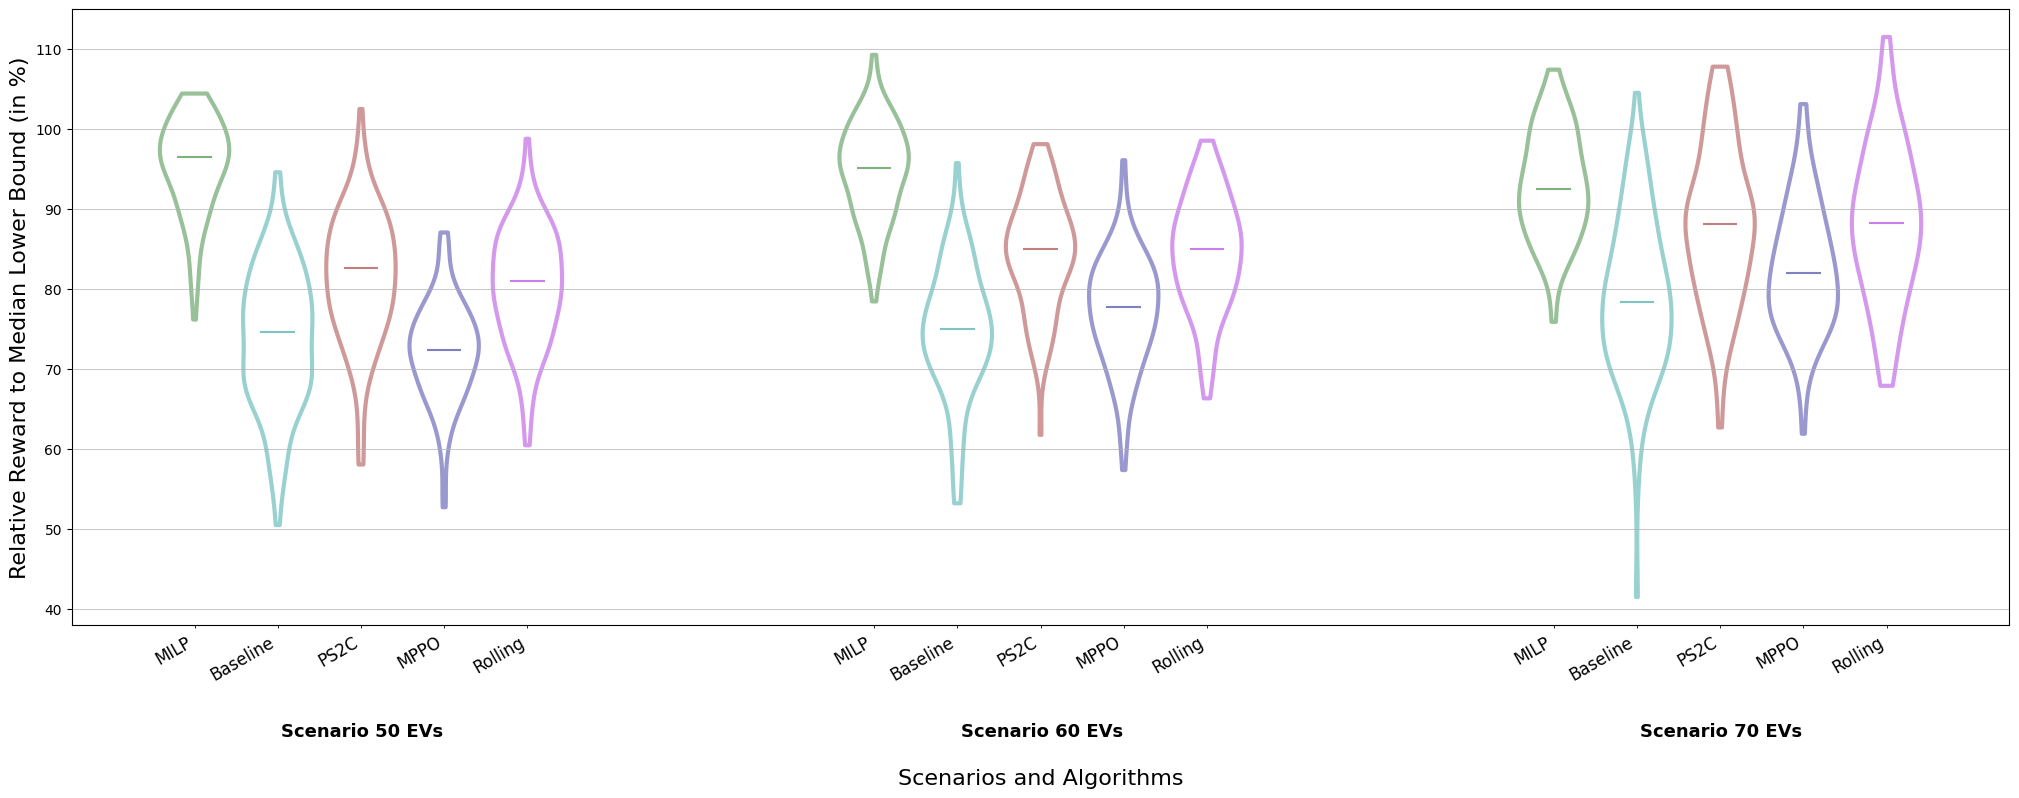

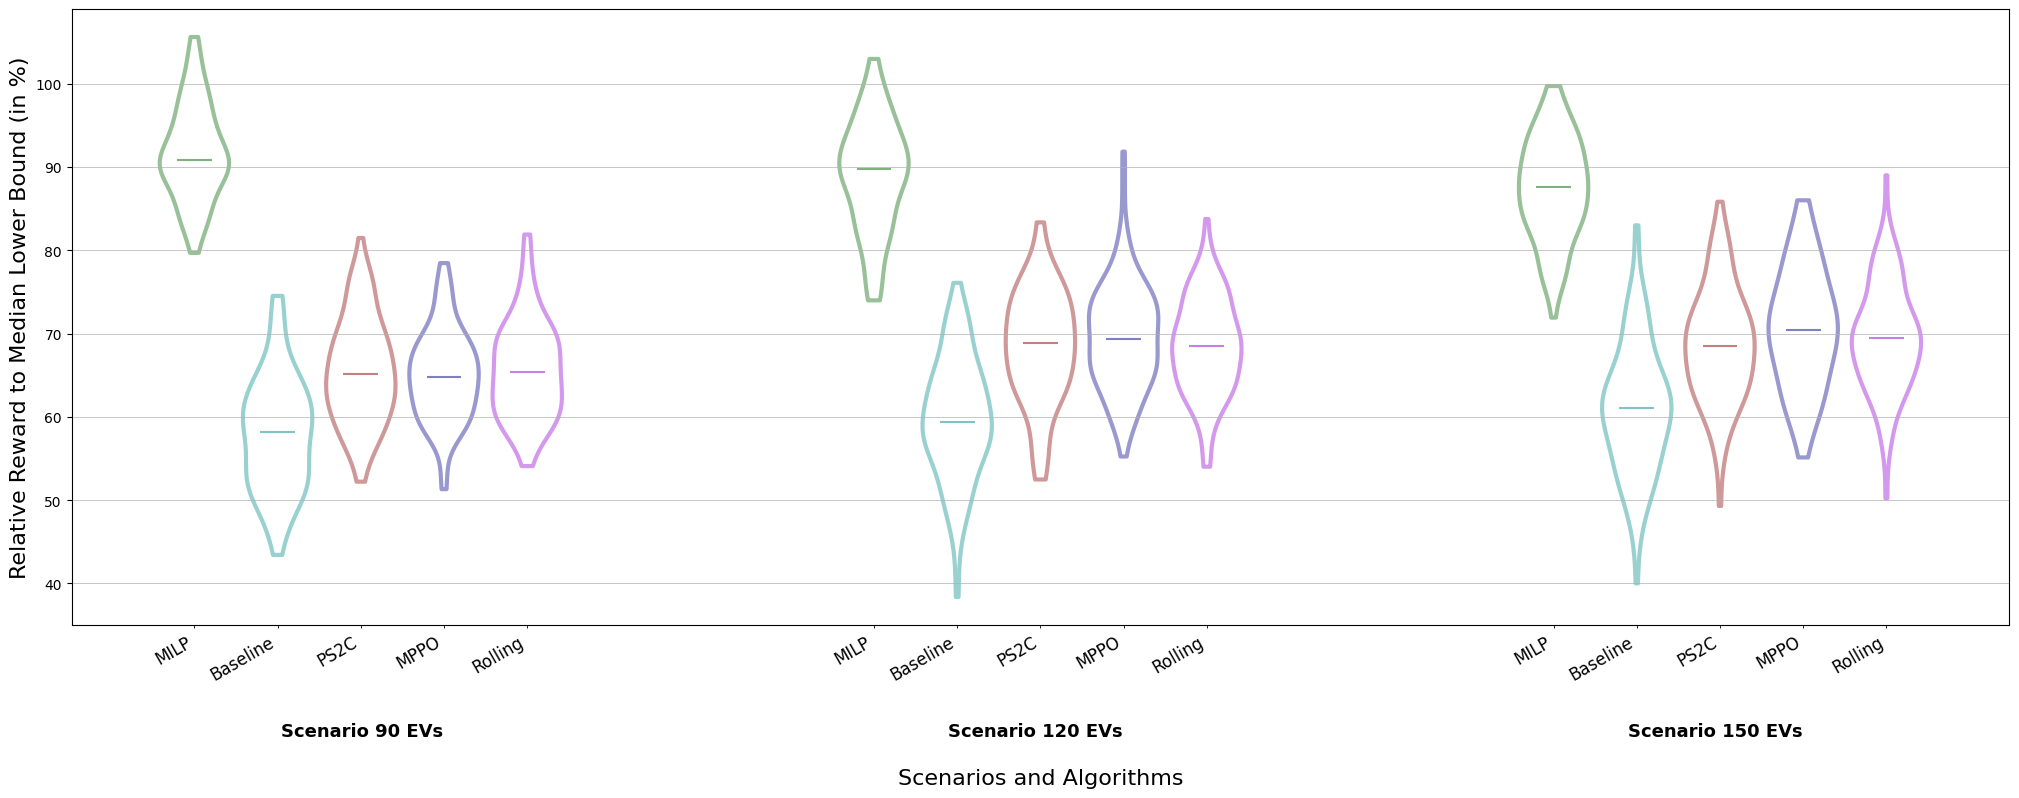

In [5]:
global_cost_distribution_perc_on_lb(df, selected_scenarios=['Scenario 50 EVs', 'Scenario 60 EVs', 'Scenario 70 EVs'],
                                    bar_width=.6, space_between_groups=-.5, figsize=(25, 8))

global_cost_distribution_perc_on_lb(df, selected_scenarios=['Scenario 90 EVs', 'Scenario 120 EVs', 'Scenario 150 EVs'],
                                    bar_width=.6, space_between_groups=-.5, figsize=(25, 8))

In [17]:
class ComputeRatioPerc:
    def __init__(self, column_name_1, column_name_2):
        self.column_name_1 = column_name_1
        self.column_name_2 = column_name_2
    
    def __call__(self, row):
        m1, s1 = map(float, row[self.column_name_1].split('±'))
        m2, s2 = map(float, row[self.column_name_2].split('±'))
        rm = m1/m2
        rs = (rm * np.sqrt((s1 / m1) ** 2 + (s2 / m2) ** 2))
        return f"{rm*100:.2f}±{rs*100:.2f}%"


selected_algorithms = ['Baseline', 'MILP', 'MPPO', 'PS2C', 'Rolling']
filtered_df = df[df['Algorithm'].isin(selected_algorithms)].copy()
cumulative_grid_limit = 75 * 24
filtered_df['Grid Limit Used'] = filtered_df['Grid used'].apply(lambda e: f"{float(e.split('±')[0])/cumulative_grid_limit*100:.2f}±{float(e.split('±')[1])/cumulative_grid_limit*100:.2f}%")
filtered_df['PV Share'] = filtered_df.apply(ComputeRatioPerc('PV used', 'Total Energy'), axis=1)
filtered_df['PV Prod. Used'] = filtered_df.apply(ComputeRatioPerc('PV used', 'Total PV'), axis=1)

from IPython.display import HTML
HTML(filtered_df.sort_values(by=['Scenario', 'Algorithm']).reset_index()[['Scenario', 'Algorithm', 'Price', 'Grid Limit Used', 'PV Share', 'PV Prod. Used']].to_html(index=False))

Scenario,Algorithm,Price,Grid Limit Used,PV Share,PV Prod. Used
Scenario 120 EVs,Baseline,86.72±16.34,57.69±5.73%,21.35±9.65%,98.93±62.62%
Scenario 120 EVs,MILP,76.31±16.04,51.22±6.92%,23.34±10.52%,98.51±62.39%
Scenario 120 EVs,MPPO,77.36±15.17,52.20±6.36%,23.05±10.35%,98.80±62.49%
Scenario 120 EVs,PS2C,74.37±16.20,50.48±6.82%,23.48±10.50%,97.85±61.79%
Scenario 120 EVs,Rolling,54.79±14.53,37.07±6.77%,28.77±12.89%,94.59±59.61%
Scenario 150 EVs,Baseline,90.02±14.46,59.39±5.73%,20.97±9.18%,99.65±60.95%
Scenario 150 EVs,MILP,78.65±15.77,52.94±6.76%,22.83±9.88%,99.04±60.36%
Scenario 150 EVs,MPPO,80.69±14.81,54.09±6.32%,22.55±9.83%,99.58±60.85%
Scenario 150 EVs,PS2C,76.88±15.39,51.93±6.71%,23.09±9.99%,98.57±60.05%
Scenario 150 EVs,Rolling,57.65±14.54,38.62±7.33%,28.34±12.21%,96.58±58.57%


In [12]:
selected_algorithms = ['Baseline', 'MILP', 'MPPO', 'PS2C', 'Rolling']
filtered_df = df[df['Algorithm'].isin(selected_algorithms)]

from IPython.display import HTML
HTML(filtered_df.sort_values(by=['Scenario', 'Algorithm']).reset_index()[['Scenario', 'Algorithm', 'Charging satisf. <80%', 'Charging satisf. >=80%', 'Waiting Time', 'Final SoC']].to_html(index=False))

Scenario,Algorithm,Charging satisf. <80%,Charging satisf. >=80%,Waiting Time,Final SoC
Scenario 120 EVs,Baseline,26.97±3.98%,30.35±4.08%,7.05±0.74,79.13±2.63%
Scenario 120 EVs,MILP,8.34±3.38%,54.53±4.27%,5.33±0.70,77.77±1.66%
Scenario 120 EVs,MPPO,12.62±2.96%,36.88±3.54%,2.90±0.41,86.38±1.80%
Scenario 120 EVs,PS2C,20.46±3.10%,35.51±3.73%,7.09±0.73,75.95±1.52%
Scenario 120 EVs,Rolling,20.14±3.23%,35.42±3.19%,8.02±0.76,67.59±2.28%
Scenario 150 EVs,Baseline,22.25±3.56%,24.77±3.46%,7.40±0.50,78.85±2.02%
Scenario 150 EVs,MILP,7.60±3.12%,45.91±3.35%,5.06±0.52,77.65±1.47%
Scenario 150 EVs,MPPO,12.65±2.90%,29.73±3.23%,3.35±0.35,84.87±1.82%
Scenario 150 EVs,PS2C,17.74±3.21%,28.40±3.00%,7.41±0.51,75.54±1.23%
Scenario 150 EVs,Rolling,15.95±2.68%,28.83±2.78%,8.55±0.59,67.84±2.13%


# Appendix: PPO/MPPO/MPPO + Post Masking Comparisons

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

STEP_PLOT_LIMIT = 9_000_000

def smooth_values(data, column_name, window_size):
    return data[column_name].rolling(window=window_size, center=True, min_periods=1).mean()

def correction_best_values(values):
    best_val = values[0]
    for i, val in enumerate(values):
        if val > best_val:
            best_val = val
        elif val < best_val:
            values[i] = best_val
    return values

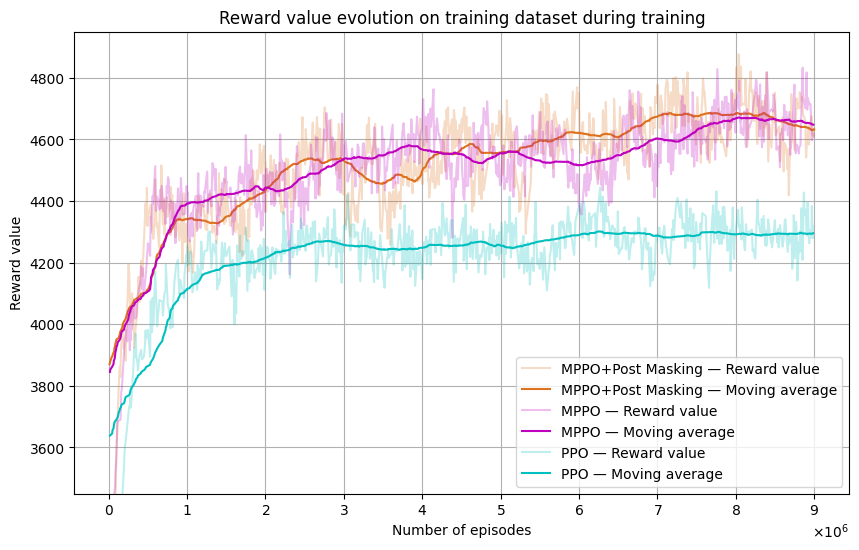

In [2]:
res_mppo = pd.read_csv('./reinforcement_learning/Adapted_MPPO_training.csv')
res_orig_mppo = pd.read_csv('./reinforcement_learning/Original_MPPO_training.csv')
res_ppo = pd.read_csv('./reinforcement_learning/PPO_training.csv')

res_mppo = res_mppo[res_mppo['Step'] <= STEP_PLOT_LIMIT]
res_orig_mppo = res_orig_mppo[res_orig_mppo['Step'] <= STEP_PLOT_LIMIT]
res_ppo = res_ppo[res_ppo['Step'] <= STEP_PLOT_LIMIT]

res_ppo['Smoothed Value'] = smooth_values(res_ppo, 'Value', 100)
res_mppo['Smoothed Value'] = smooth_values(res_mppo, 'Value', 100)
res_orig_mppo['Smoothed Value'] = smooth_values(res_orig_mppo, 'Value', 100)

plt.figure(figsize=(10, 6))
plt.plot(res_mppo['Step'], res_mppo['Value'], marker=None, linestyle='-', alpha=.25, color='#de721e', label="MPPO+Post Masking — Reward value")
plt.plot(res_mppo['Step'], res_mppo['Smoothed Value'], marker=None, linestyle='-', alpha=1., color='#de721e', label="MPPO+Post Masking — Moving average")
plt.plot(res_orig_mppo['Step'], res_orig_mppo['Value'], marker=None, linestyle='-', alpha=.25, color='m', label="MPPO — Reward value")
plt.plot(res_orig_mppo['Step'], res_orig_mppo['Smoothed Value'], marker=None, linestyle='-', alpha=1., color='m', label="MPPO — Moving average")
plt.plot(res_ppo['Step'], res_ppo['Value'], marker=None, linestyle='-', alpha=.25, color='c', label="PPO — Reward value")
plt.plot(res_ppo['Step'], res_ppo['Smoothed Value'], marker=None, linestyle='-', alpha=1., color='c', label="PPO — Moving average")
plt.title('Reward value evolution on training dataset during training')
plt.xlabel('Number of episodes')
plt.ylabel('Reward value')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
ticks = list(range(0, STEP_PLOT_LIMIT+1_000_000, 1_000_000))
plt.xticks(ticks, rotation='horizontal')
plt.ylim(3450, 4950)
plt.grid(True)
plt.legend()

plt.savefig('rl_training.png', dpi=600)
plt.show()

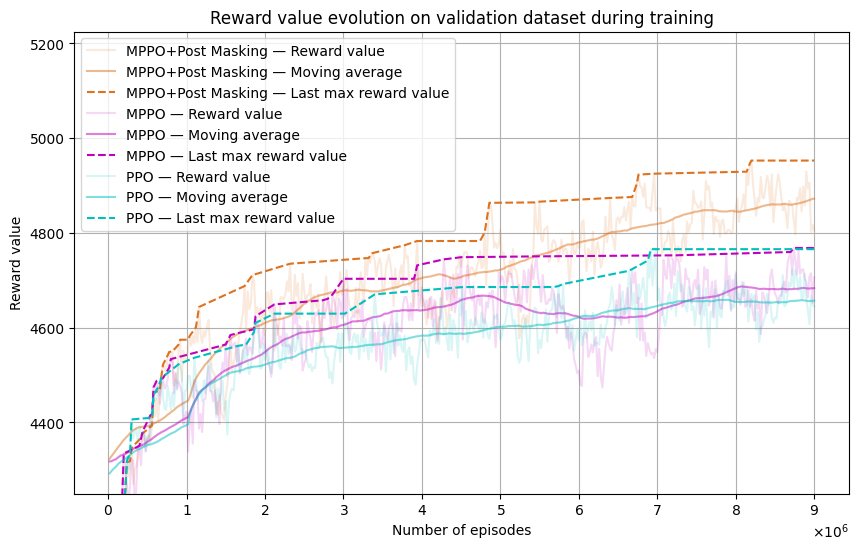

In [3]:
res_mppo_best = pd.read_csv('./reinforcement_learning/Adapted_MPPO_evaluation_best.csv')
res_orig_mppo_best = pd.read_csv('./reinforcement_learning/Original_MPPO_evaluation_best.csv')
res_ppo_best = pd.read_csv('./reinforcement_learning/PPO_evaluation_best.csv')
res_mppo = pd.read_csv('./reinforcement_learning/Adapted_MPPO_evaluation.csv')
res_orig_mppo = pd.read_csv('./reinforcement_learning/Original_MPPO_evaluation.csv')
res_ppo = pd.read_csv('./reinforcement_learning/PPO_evaluation.csv')

res_mppo_best = res_mppo_best[res_mppo_best['Step'] <= STEP_PLOT_LIMIT]
res_orig_mppo_best = res_orig_mppo_best[res_orig_mppo_best['Step'] <= STEP_PLOT_LIMIT]
res_ppo_best = res_ppo_best[res_ppo_best['Step'] <= STEP_PLOT_LIMIT]
res_mppo = res_mppo[res_mppo['Step'] <= STEP_PLOT_LIMIT]
res_orig_mppo = res_orig_mppo[res_orig_mppo['Step'] <= STEP_PLOT_LIMIT]
res_ppo = res_ppo[res_ppo['Step'] <= STEP_PLOT_LIMIT]

res_ppo['Smoothed Value'] = smooth_values(res_ppo, 'Value', 100)
res_mppo['Smoothed Value'] = smooth_values(res_mppo, 'Value', 100)
res_orig_mppo['Smoothed Value'] = smooth_values(res_orig_mppo, 'Value', 100)
res_ppo_best['Value'] = correction_best_values(res_ppo_best['Value'].copy())
res_mppo_best['Value'] = correction_best_values(res_mppo_best['Value'].copy())
res_orig_mppo_best['Value'] = correction_best_values(res_orig_mppo_best['Value'].copy())
res_ppo_best.loc[max(res_ppo_best.index)+1] = [.0, res_ppo['Step'].to_numpy()[-1], res_ppo_best['Value'].to_numpy()[-1]]
res_mppo_best.loc[max(res_mppo_best.index)+1] = [.0, res_mppo['Step'].to_numpy()[-1], res_mppo_best['Value'].to_numpy()[-1]]
res_orig_mppo_best.loc[max(res_orig_mppo_best.index)+1] = [.0, res_orig_mppo['Step'].to_numpy()[-1], res_orig_mppo_best['Value'].to_numpy()[-1]]

plt.figure(figsize=(10, 6))
plt.plot(res_mppo['Step'], res_mppo['Value'], marker=None, linestyle='-', alpha=.15, color='#de721e', label="MPPO+Post Masking — Reward value")
plt.plot(res_mppo['Step'], res_mppo['Smoothed Value'], marker=None, linestyle='-', alpha=.5, color='#de721e', label="MPPO+Post Masking — Moving average")
plt.plot(res_mppo_best['Step'], res_mppo_best['Value'], marker=None, linestyle='--', alpha=1., color='#de721e', label="MPPO+Post Masking — Last max reward value")
plt.plot(res_orig_mppo['Step'], res_orig_mppo['Value'], marker=None, linestyle='-', alpha=.15, color='m', label="MPPO — Reward value")
plt.plot(res_orig_mppo['Step'], res_orig_mppo['Smoothed Value'], marker=None, linestyle='-', alpha=.5, color='m', label="MPPO — Moving average")
plt.plot(res_orig_mppo_best['Step'], res_orig_mppo_best['Value'], marker=None, linestyle='--', alpha=1., color='m', label="MPPO — Last max reward value")
plt.plot(res_ppo['Step'], res_ppo['Value'], marker=None, linestyle='-', alpha=.15, color='c', label="PPO — Reward value")
plt.plot(res_ppo['Step'], res_ppo['Smoothed Value'], marker=None, linestyle='-', alpha=.5, color='c', label="PPO — Moving average")
plt.plot(res_ppo_best['Step'], res_ppo_best['Value'], marker=None, linestyle='--', alpha=1., color='c', label="PPO — Last max reward value")
plt.title('Reward value evolution on validation dataset during training')
plt.xlabel('Number of episodes')
plt.ylabel('Reward value')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
ticks = list(range(0, STEP_PLOT_LIMIT+1_000_000, 1_000_000))
plt.xticks(ticks, rotation='horizontal')
plt.ylim(4250, 5225)
plt.grid(True)
plt.legend()

plt.savefig('rl_evaluation.png', dpi=600)
plt.show()

# Appendix: MPPO + Post Masking with/out price prediction and without any prediction comparisons

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

STEP_PLOT_LIMIT = 9_000_000

def smooth_values(data, column_name, window_size):
    return data[column_name].rolling(window=window_size, center=True, min_periods=1).mean()

def correction_best_values(values):
    best_val = values[0]
    for i, val in enumerate(values):
        if val > best_val:
            best_val = val
        elif val < best_val:
            values[i] = best_val
    return values

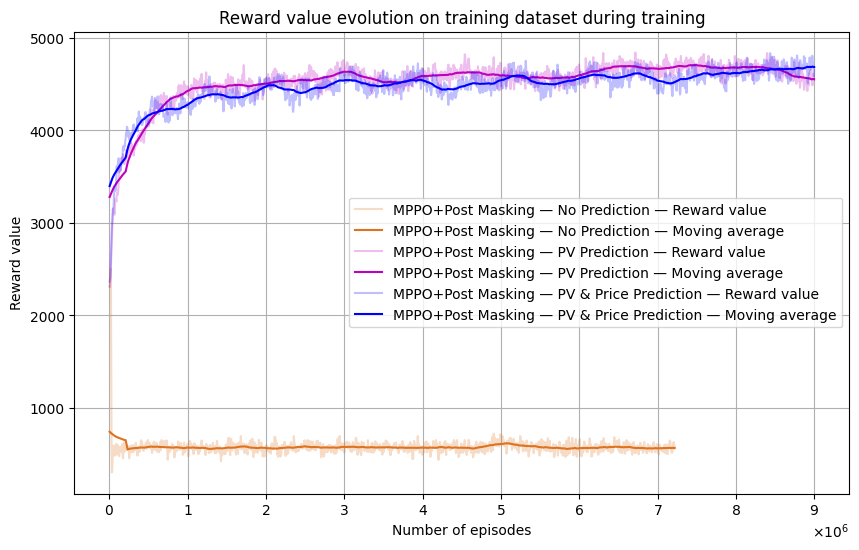

In [5]:
res_mppo_no_pred = pd.read_csv('./reinforcement_learning/Adapted_MPPO_without_any_prediction_training.csv')
res_mppo_no_price = pd.read_csv('./reinforcement_learning/Adapted_MPPO_without_price_prediction_training.csv')
res_mppo_price = pd.read_csv('./reinforcement_learning/Adapted_MPPO_with_price_prediction_training.csv')
res_orig_mppo = pd.read_csv('./reinforcement_learning/Original_MPPO_with_price_prediction_training.csv')

res_mppo_no_pred = res_mppo_no_pred[res_mppo_no_pred['Step'] <= STEP_PLOT_LIMIT]
res_mppo_no_price = res_mppo_no_price[res_mppo_no_price['Step'] <= STEP_PLOT_LIMIT]
res_mppo_price = res_mppo_price[res_mppo_price['Step'] <= STEP_PLOT_LIMIT]
res_orig_mppo = res_orig_mppo[res_orig_mppo['Step'] <= STEP_PLOT_LIMIT]

res_mppo_no_pred['Smoothed Value'] = smooth_values(res_mppo_no_pred, 'Value', 100)
res_mppo_no_price['Smoothed Value'] = smooth_values(res_mppo_no_price, 'Value', 100)
res_mppo_price['Smoothed Value'] = smooth_values(res_mppo_price, 'Value', 100)
res_orig_mppo['Smoothed Value'] = smooth_values(res_orig_mppo, 'Value', 100)

plt.figure(figsize=(10, 6))
plt.plot(res_mppo_no_pred['Step'], res_mppo_no_pred['Value'], marker=None, linestyle='-', alpha=.25, color='#de721e', label="MPPO+Post Masking — No Prediction — Reward value")
plt.plot(res_mppo_no_pred['Step'], res_mppo_no_pred['Smoothed Value'], marker=None, linestyle='-', alpha=1., color='#de721e', label="MPPO+Post Masking — No Prediction — Moving average")
plt.plot(res_mppo_no_price['Step'], res_mppo_no_price['Value'], marker=None, linestyle='-', alpha=.25, color='m', label="MPPO+Post Masking — PV Prediction — Reward value")
plt.plot(res_mppo_no_price['Step'], res_mppo_no_price['Smoothed Value'], marker=None, linestyle='-', alpha=1., color='m', label="MPPO+Post Masking — PV Prediction — Moving average")
plt.plot(res_mppo_price['Step'], res_mppo_price['Value'], marker=None, linestyle='-', alpha=.25, color='b', label="MPPO+Post Masking — PV & Price Prediction — Reward value")
plt.plot(res_mppo_price['Step'], res_mppo_price['Smoothed Value'], marker=None, linestyle='-', alpha=1., color='b', label="MPPO+Post Masking — PV & Price Prediction — Moving average")
plt.title('Reward value evolution on training dataset during training')
plt.xlabel('Number of episodes')
plt.ylabel('Reward value')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
ticks = list(range(0, STEP_PLOT_LIMIT+1_000_000, 1_000_000))
plt.xticks(ticks, rotation='horizontal')
plt.grid(True)
plt.legend()

plt.savefig('rl_training_price.png', dpi=600)
plt.show()

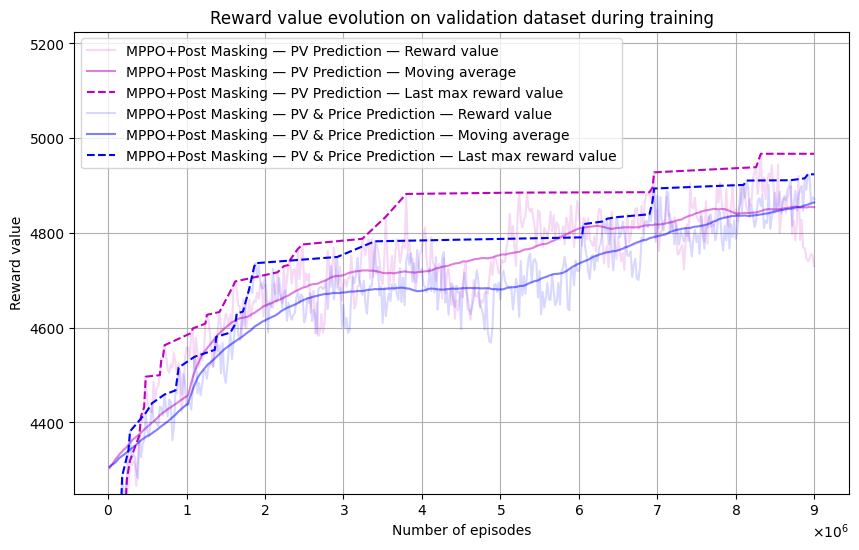

In [4]:
res_mppo_no_price_best = pd.read_csv('./reinforcement_learning/Adapted_MPPO_without_price_prediction_evaluation_best.csv')
res_mppo_price_best = pd.read_csv('./reinforcement_learning/Adapted_MPPO_with_price_prediction_evaluation_best.csv')
res_mppo_no_price = pd.read_csv('./reinforcement_learning/Adapted_MPPO_without_price_prediction_evaluation.csv')
res_mppo_price = pd.read_csv('./reinforcement_learning/Adapted_MPPO_with_price_prediction_evaluation.csv')

res_mppo_no_price_best = res_mppo_no_price_best[res_mppo_no_price_best['Step'] <= STEP_PLOT_LIMIT]
res_mppo_price_best = res_mppo_price_best[res_mppo_price_best['Step'] <= STEP_PLOT_LIMIT]
res_mppo_no_price = res_mppo_no_price[res_mppo_no_price['Step'] <= STEP_PLOT_LIMIT]
res_mppo_price = res_mppo_price[res_mppo_price['Step'] <= STEP_PLOT_LIMIT]

res_mppo_no_price['Smoothed Value'] = smooth_values(res_mppo_no_price, 'Value', 100)
res_mppo_price['Smoothed Value'] = smooth_values(res_mppo_price, 'Value', 100)
res_mppo_no_price_best['Value'] = correction_best_values(res_mppo_no_price_best['Value'].copy())
res_mppo_price_best['Value'] = correction_best_values(res_mppo_price_best['Value'].copy())
res_mppo_no_price_best.loc[max(res_mppo_no_price_best.index)+1] = [.0, res_mppo_no_price['Step'].to_numpy()[-1], res_mppo_no_price_best['Value'].to_numpy()[-1]]
res_mppo_price_best.loc[max(res_mppo_price_best.index)+1] = [.0, res_mppo_price['Step'].to_numpy()[-1], res_mppo_price_best['Value'].to_numpy()[-1]]

plt.figure(figsize=(10, 6))
plt.plot(res_mppo_no_price['Step'], res_mppo_no_price['Value'], marker=None, linestyle='-', alpha=.15, color='m', label="MPPO+Post Masking — PV Prediction — Reward value")
plt.plot(res_mppo_no_price['Step'], res_mppo_no_price['Smoothed Value'], marker=None, linestyle='-', alpha=.5, color='m', label="MPPO+Post Masking — PV Prediction — Moving average")
plt.plot(res_mppo_no_price_best['Step'], res_mppo_no_price_best['Value'], marker=None, linestyle='--', alpha=1., color='m', label="MPPO+Post Masking — PV Prediction — Last max reward value")
plt.plot(res_mppo_price['Step'], res_mppo_price['Value'], marker=None, linestyle='-', alpha=.15, color='b', label="MPPO+Post Masking — PV & Price Prediction — Reward value")
plt.plot(res_mppo_price['Step'], res_mppo_price['Smoothed Value'], marker=None, linestyle='-', alpha=.5, color='b', label="MPPO+Post Masking — PV & Price Prediction — Moving average")
plt.plot(res_mppo_price_best['Step'], res_mppo_price_best['Value'], marker=None, linestyle='--', alpha=1., color='b', label="MPPO+Post Masking — PV & Price Prediction — Last max reward value")
plt.title('Reward value evolution on validation dataset during training')
plt.xlabel('Number of episodes')
plt.ylabel('Reward value')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
ticks = list(range(0, STEP_PLOT_LIMIT+1_000_000, 1_000_000))
plt.xticks(ticks, rotation='horizontal')
plt.ylim(4250, 5225)
plt.grid(True)
plt.legend()

plt.savefig('rl_evaluation_price.png', dpi=600)
plt.show()